## Denoising Diffusion Probabilistic Models (DDPMs) — Lab Overview

In this lab, you will build a **diffusion model from scratch** using PyTorch, trained on the MNIST handwritten digits dataset. Diffusion models are the core technology behind modern image generators like DALL-E and Stable Diffusion — they work by learning to reverse a gradual noising process. The lab is structured into four checkpoints:

- **Checkpoint 1 — Forward Diffusion:** Implement the *forward diffusion process*, which defines a noise schedule and a closed-form formula for corrupting a clean image into pure Gaussian noise over 1,000 timesteps.
- **Checkpoint 2 — Reverse Diffusion (Conceptual):** Implement the *reverse diffusion process* as a conceptual demo — using the actual noise from the forward pass as a stand-in for a real predictor, to verify that the denoising math is correct before any model is involved.
- **Checkpoint 3 — U-Net Training & Generation:** Build and train a **U-Net** — a convolutional neural network with residual blocks, sinusoidal timestep embeddings, and encoder-decoder skip connections — to predict the noise in a corrupted image. Once trained, the U-Net replaces the cheat answer from Checkpoint 2, enabling the model to generate brand new handwritten digits starting from pure random noise.

Additional Resources (super helpful!):

https://github.com/FilippoMB/Diffusion_models_tutorial

## [CHECKPOINT 0] PRESETS

### IMPORTS

In [ ]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import math
import torch.nn as nn
import torch.optim as optim
import os
import torch.nn.functional as F

### LOAD & PREPROCESS MNIST DATA

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Define a series of transformations for the MNIST images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to range [-1, 1]
])

# 3. Load the MNIST training dataset
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 4. Create a DataLoader for the MNIST dataset
batch_size = 64
data_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True)


Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.26MB/s]


### SANITY CHECK FOR THE DATA

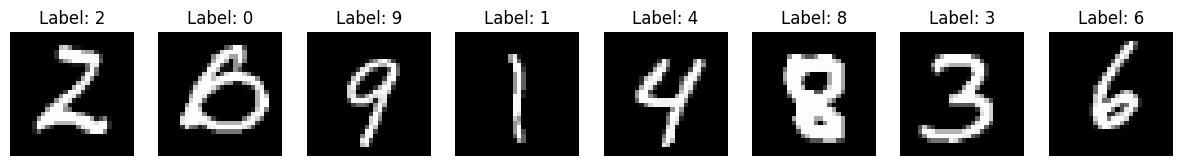

In [ ]:
# 5. Retrieve a single batch of images from the DataLoader
data_iter = iter(data_loader)
images, labels = next(data_iter)

# 6. Select a few images from the batch
num_images_to_show = 8
selected_images = images[:num_images_to_show]
selected_labels = labels[:num_images_to_show]

# 7. Visualize the selected original MNIST images
fig, axes = plt.subplots(1, num_images_to_show, figsize=(15, 2))

for i, (image, label) in enumerate(zip(selected_images, selected_labels)):
    # Denormalize the image from [-1, 1] to [0, 1] for visualization
    image = (image * 0.5) + 0.5  # inverse of transforms.Normalize((0.5,), (0.5,))
    image = image.squeeze().cpu().numpy() # Remove channel dimension and convert to numpy

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {label.item()}")
    axes[i].axis('off')
plt.show()

## [CHECKPOINT 1] FORWARD DIFFUSION

### DIFFUSION PARAMETERS

In [ ]:

# 1. Define the number of diffusion timesteps
num_diffusion_timesteps = 1000

# 2. Define a noise schedule for beta values (linear schedule)
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, num_diffusion_timesteps)

# Calculate alpha values
alphas = 1.0 - betas

# 3. Calculate the cumulative product of (1 - betas) as alphas_cumprod
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]])

# Calculate the square roots for the forward diffusion formula
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

### FORWARD PROCESS

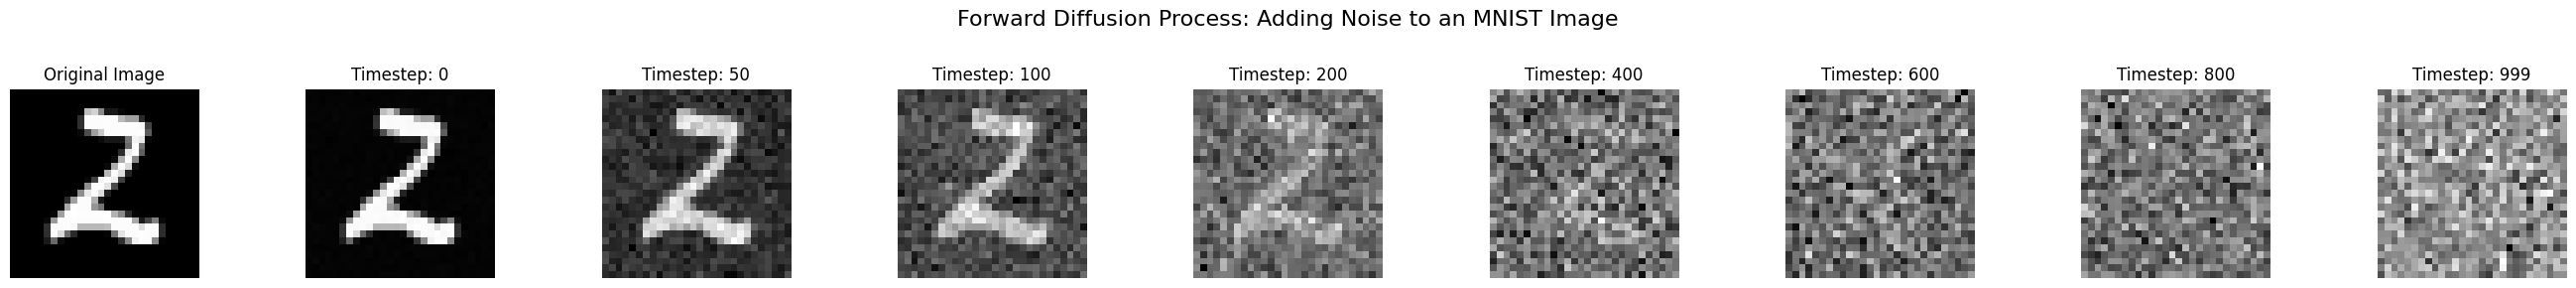

In [6]:
#  Define a function, forward_diffusion_sample
def forward_diffusion_sample(x_0, t, alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    """
    Samples from the forward diffusion process (adds noise to the image).
    x_0: original image
    t: timestep
    alphas_cumprod: cumulative product of alphas
    sqrt_one_minus_alphas_cumprod: square root of (1 - alphas_cumprod)
    """
    # Reshape t for broadcasting (e.g., from (batch_size,) to (batch_size, 1, 1, 1))
    t = t.view(-1, 1, 1, 1)

    # Calculate sqrt_alpha_cumprod for the given timestep t
    sqrt_alpha_cumprod_t = sqrt_alphas_cumprod[t].to(x_0.device)

    # Calculate sqrt_one_minus_alpha_cumprod for the given timestep t
    sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t].to(x_0.device)

    # Sample noise from a standard normal distribution with the same shape as the image
    noise = torch.randn_like(x_0)

    # Return the noisy image using the formula: sqrt_alpha_cumprod * original_image + sqrt_one_minus_alpha_cumprod * noise
    return sqrt_alpha_cumprod_t * x_0 + sqrt_one_minus_alpha_cumprod_t * noise, noise

#  Select a single image from the data_loader to demonstrate the forward diffusion.
# We'll reuse the `images` and `labels` from the previous visualization cell, taking the first one.
single_image = images[0:1]

#  Choose a few intermediate timesteps to visualize the noisy images.
timesteps_to_visualize = [0, 50, 100, 200, 400, 600, 800, 999]

# Create a figure with subplots to display the original image and the noisy images.
num_plots = len(timesteps_to_visualize) + 1 # +1 for the original image
fig, axes = plt.subplots(1, num_plots, figsize=(3 * num_plots, 3))

# Display the original image first
# Denormalize the image from [-1, 1] to [0, 1] for visualization
original_display = (single_image[0] * 0.5) + 0.5 # inverse of transforms.Normalize((0.5,), (0.5,))
original_display = original_display.squeeze().cpu().numpy()
axes[0].imshow(original_display, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Iterate through the chosen timesteps, call the forward_diffusion_sample function,
# denormalize it, and display it in a subplot.
for i, t_val in enumerate(timesteps_to_visualize):
    t_tensor = torch.tensor([t_val])
    noisy_image, _ = forward_diffusion_sample(single_image, t_tensor, alphas_cumprod, sqrt_one_minus_alphas_cumprod)

    # Denormalize the noisy image from [-1, 1] to [0, 1] for visualization
    noisy_display = (noisy_image[0] * 0.5) + 0.5
    noisy_display = noisy_display.squeeze().cpu().numpy()

    axes[i+1].imshow(noisy_display, cmap='gray')
    axes[i+1].set_title(f'Timestep: {t_val}')
    axes[i+1].axis('off')

#  Add a main title to the figure.
plt.suptitle('Forward Diffusion Process: Adding Noise to an MNIST Image', fontsize=16)

#  Display the plot.
plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent suptitle overlap
plt.show()


## [CHECKPOINT 2] REVERSE DIFFUSION PROCESS

In [17]:
#  Store the original image and its corresponding actual noise for each timestep
# The single_image variable already holds the original image from previous steps
# We'll generate the full forward sequence for this single image.
alphas_cumprod = alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)


#  Define a function 'extract' to retrieve specific values from a tensor at given timesteps
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

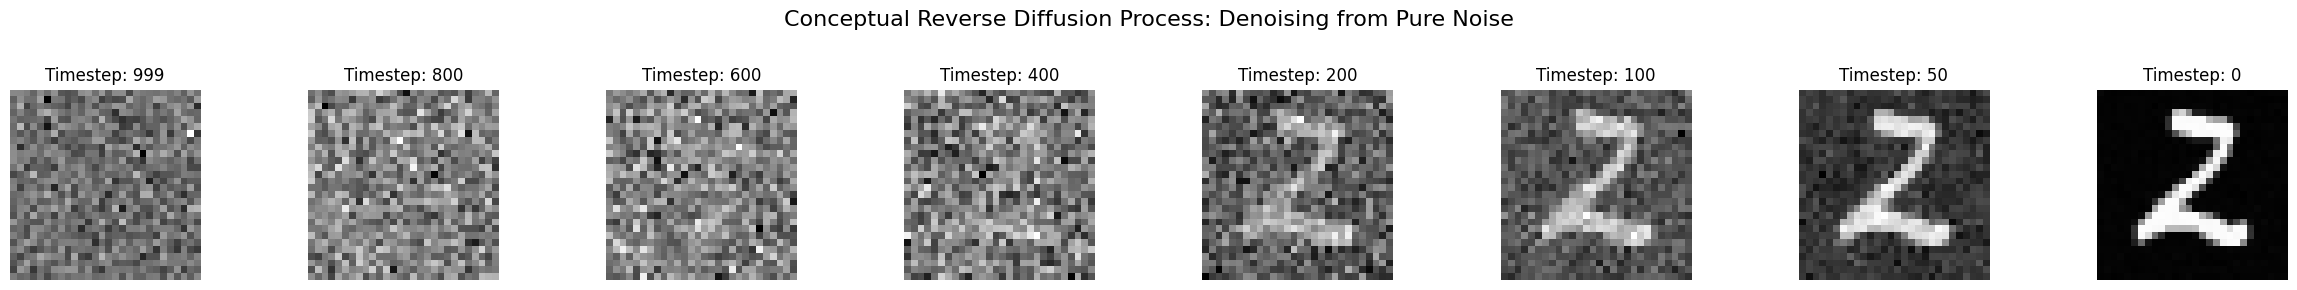

In [18]:
#  Implement a conceptual p_sample function
def p_sample(x_t, t, predicted_noise, betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev):
    """
    Conceptual reverse diffusion step: estimates x_{t-1} from x_t and predicted noise.
    For this conceptual demo, predicted_noise is the actual noise from the forward process.
    """
    # Get diffusion parameters for the current timestep t
    beta_t = extract(betas, t, x_t.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x_t.shape)
    alpha_cumprod_t = extract(alphas_cumprod, t, x_t.shape)
    alpha_cumprod_t_prev = extract(alphas_cumprod_prev, t, x_t.shape)

    # Calculate mean of x_{t-1}
    # Mean formula: 1/sqrt(alpha_t) * (x_t - (beta_t / sqrt(1 - alpha_cumprod_t)) * predicted_noise)
    mean = sqrt_recip_alpha_t * (x_t - beta_t * predicted_noise / torch.sqrt(1 - alpha_cumprod_t))

    # If t is 0, there is no noise to add, so return the mean (which is x_0_hat)
    if t.min() == 0:
        return mean

    # Calculate variance for x_{t-1}
    # Variance formula: beta_t * (1 - alpha_cumprod_t_prev) / (1 - alpha_cumprod_t)
    variance = beta_t * (1.0 - alpha_cumprod_t_prev) / (1.0 - alpha_cumprod_t)
    log_variance = torch.log(variance)

    # Sample noise from a standard normal distribution
    noise = torch.randn_like(x_t)

    # Return x_{t-1} using the formula: mean + sqrt(variance) * noise
    return mean + torch.exp(0.5 * log_variance) * noise

#  Implement a conceptual p_sample_loop function that collects images for visualization
def p_sample_loop(num_diffusion_timesteps, x_t_sequence, betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev):
    current_img = x_t_sequence[-1:] # Start with the fully noisy image (x_T)

    # Define the specific timesteps we want to *show* in the visualization.
    # These should be in descending order to match the denoising process flow visually.
    visualization_output_timesteps = [num_diffusion_timesteps - 1, 800, 600, 400, 200, 100, 50, 0]

    images_to_display = [] # Store (image_tensor, timestep_value)

    # Add the initial fully noisy image (x_T) as the very first image in the sequence.
    # We use x_t_sequence[-1] for the true x_T, labeled with its timestep.
    images_to_display.append((current_img.cpu(), num_diffusion_timesteps - 1))

    # Loop from T-1 down to 0 for reverse diffusion steps
    for i in range(num_diffusion_timesteps - 1, -1, -1):
        t_tensor = torch.tensor([i], device=current_img.device)
        alpha_bar_t = extract(alphas_cumprod, t_tensor, current_img.shape)
        predicted_noise = (current_img - torch.sqrt(alpha_bar_t) * single_image) / torch.sqrt(1 - alpha_bar_t)

        # Apply one denoising step: calculate x_{i-1} from current_img (which is x_i)
        next_img = p_sample(current_img, t_tensor, predicted_noise, betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev)

        # Update current_img to be x_{i-1} for the next iteration
        current_img = next_img

        # Check if the *result's* timestep (i-1) is one we want to display
        if (i - 1) in visualization_output_timesteps:
            images_to_display.append((current_img.cpu(), i - 1))

    # The list `images_to_display` is already populated in the desired order:
    # [(x_T, 999), (x_800, 800), ..., (x_0, 0)]
    # No further sorting is needed for direct plotting.
    return images_to_display


# Ensure all diffusion parameters are on the correct device for the conceptual p_sample_loop
betas = betas.to(device)
sqrt_recip_alphas = sqrt_recip_alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)
alphas_cumprod_prev = alphas_cumprod_prev.to(device)


# Run the reverse diffusion loop to get the images for visualization
reconstructed_images_with_timesteps = p_sample_loop(num_diffusion_timesteps, x_t_sequence, betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev)


#  Visualize the reverse diffusion process
num_plots = len(reconstructed_images_with_timesteps) # This will correctly be 8
fig, axes = plt.subplots(1, num_plots, figsize=(3 * num_plots, 3))

# Iterate directly through the prepared list and plot each image
for i, (image_tensor, t_val) in enumerate(reconstructed_images_with_timesteps):
    # Denormalize the image from [-1, 1] to [0, 1] for visualization
    display_image = (image_tensor[0] * 0.5) + 0.5
    display_image = display_image.squeeze().cpu().numpy()

    # Plot on the corresponding axis
    axes[i].imshow(display_image, cmap='gray')
    axes[i].set_title(f'Timestep: {t_val}')
    axes[i].axis('off')

plt.suptitle('Conceptual Reverse Diffusion Process: Denoising from Pure Noise', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent suptitle overlap
plt.show()

# Conceptual reverse diffusion visualization completed showing progressive denoising.

## [ FINAL CHECKPOINT] UNET NOISE PREDICTION

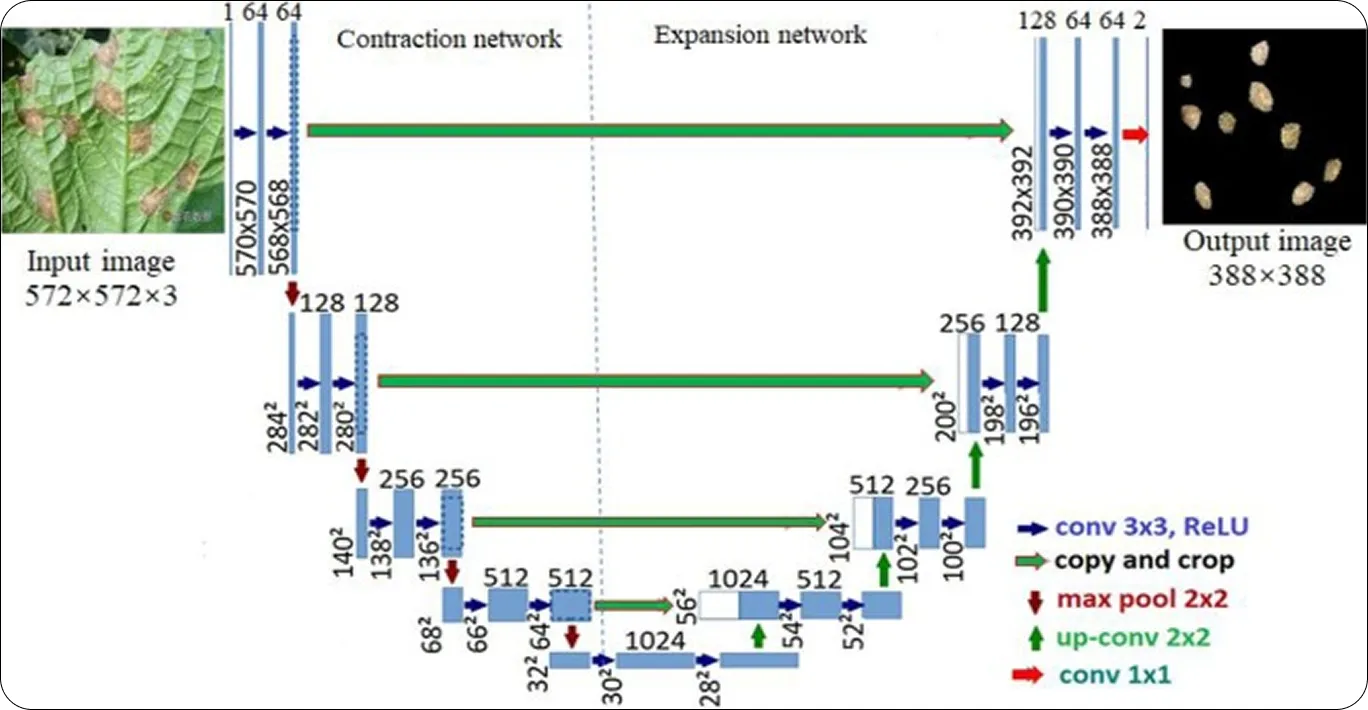

### UNET BACKBONE ARCHITECTURE

In [23]:
#  TimeStepEmbedding class
class TimeStepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        # Positional Encoding for timestep
        # From "Attention Is All You Need" (Vaswani et al., 2017)
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=t.device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

        # If dim is odd, we might need to pad or truncate one of the sin/cos parts
        if self.dim % 2 == 1:
            embeddings = F.pad(embeddings, (0, 1), mode='constant', value=0.0)

        return self.mlp(embeddings)

#  ResidualBlock class
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1)
        )
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        self.conv2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv2d(out_channels, out_channels, 3, padding=1)
        )
        # Residual connection
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_emb):
        h = self.conv1(x)
        # Add time_emb after first conv layer
        h += self.time_mlp(time_emb)[:, :, None, None]
        h = self.conv2(h)
        return h + self.residual_conv(x)

#  Upsample class
class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channels, out_channels, 3, padding=1)
        )

    def forward(self, x):
        return self.upsample_conv(x)

#  Downsample class
class Downsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.downsample_conv = nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.downsample_conv(x)


In [24]:
#  UNet class for noise prediction
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, model_dims=[32, 64, 128, 256], time_emb_dim=256):
        super().__init__()
        self.time_emb_dim = time_emb_dim

        # Timestep embedding
        self.time_mlp = TimeStepEmbedding(time_emb_dim)

        # Initial convolution
        self.initial_conv = nn.Conv2d(in_channels, model_dims[0], 3, padding=1)

        # Encoder (Downsampling Path)
        self.downs = nn.ModuleList([])
        skips_channels = [] # To store channels for skip connections (output of RB, before Downsample)

        current_channels = model_dims[0]
        for i in range(len(model_dims) - 1):
            next_channels = model_dims[i+1]
            self.downs.append(nn.ModuleList([
                ResidualBlock(current_channels, current_channels, time_emb_dim),
                ResidualBlock(current_channels, current_channels, time_emb_dim),
                Downsample(current_channels, next_channels) # Always downsample and change channels
            ]))
            skips_channels.append(current_channels) # Store channels *before* downsampling for skip connection
            current_channels = next_channels # Update current_channels for the next stage

        # Bottleneck
        # At this point, current_channels is model_dims[-1]
        mid_dim = current_channels
        self.mid_block1 = ResidualBlock(mid_dim, mid_dim, time_emb_dim)
        self.mid_block2 = ResidualBlock(mid_dim, mid_dim, time_emb_dim)

        # Decoder (Upsampling Path)
        self.ups = nn.ModuleList([])
        num_resolutions = len(model_dims)

        for i in reversed(range(num_resolutions - 1)): # i goes from num_resolutions-2 down to 0
            curr_channels_to_upsample = model_dims[i+1] # The current feature map (x) will have these channels before upsampling
            skip_channels = skips_channels[i] # Channels of the skip connection from encoder
            target_channels_after_upsample = model_dims[i] # Channels of the feature map after upsampling

            self.ups.append(nn.ModuleList([
                Upsample(curr_channels_to_upsample, target_channels_after_upsample), # Upsample x to match skip resolution/channels
                ResidualBlock(target_channels_after_upsample + skip_channels, target_channels_after_upsample, time_emb_dim), # Takes concatenated input
                ResidualBlock(target_channels_after_upsample, target_channels_after_upsample, time_emb_dim)
            ]))

        # Final output convolution
        self.final_conv = nn.Sequential(
            nn.GroupNorm(8, model_dims[0]),
            nn.SiLU(),
            nn.Conv2d(model_dims[0], out_channels, 1)
        )

    def forward(self, x, time):
        # Timestep embedding
        time_emb = self.time_mlp(time)

        # Initial convolution
        x = self.initial_conv(x) # Channels: model_dims[0]

        h = [] # To store skip connections

        # Downsampling path
        for rbs1, rbs2, downsample in self.downs:
            x = rbs1(x, time_emb)
            x = rbs2(x, time_emb)
            h.append(x) # Store for skip connection (x has channels for model_dims[i])
            x = downsample(x) # x now has channels model_dims[i+1]

        # Bottleneck
        x = self.mid_block1(x, time_emb)
        x = self.mid_block2(x, time_emb)

        # Upsampling path
        for upsample_layer, rbs1, rbs2 in self.ups:
            # 1. Upsample x to match the resolution of the corresponding skip connection
            x = upsample_layer(x)

            # 2. Pop the latest skip connection
            skip_connection = h.pop()

            # 3. Concatenate upsampled x with skip_connection
            x = torch.cat((x, skip_connection), dim=1)

            # 4. Pass through residual blocks
            x = rbs1(x, time_emb)
            x = rbs2(x, time_emb)

        # Final output layer
        return self.final_conv(x)

### TRAINING THE UNET

### TRAINING PARAMETERS

In [25]:
#  Define the number of diffusion timesteps
num_diffusion_timesteps = 500 # Reduced from 1000 to 500 for faster training

#  Define a noise schedule for beta values (linear schedule)
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, num_diffusion_timesteps).to(device)

# Calculate alpha values
alphas = 1.0 - betas

#  Calculate the cumulative product of (1 - betas) as alphas_cumprod
alphas_cumprod = torch.cumprod(alphas, axis=0).to(device)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]]).to(device)

# Calculate the square roots for the forward diffusion formula
sqrt_recip_alphas = torch.sqrt(1.0 / alphas).to(device)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod).to(device)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod).to(device)

print(f"Diffusion parameters re-initialized with {num_diffusion_timesteps} timesteps.")

Diffusion parameters re-initialized with 500 timesteps.


In [26]:
model = UNet(in_channels=1, out_channels=1, model_dims=[32, 64, 128]).to(device)
# Define the Adam optimizer with a reduced learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-4)
# Define a learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# Define the Mean Squared Error (MSE) loss function
loss_fn = nn.MSELoss()


### TRAINING LOOP

In [ ]:
import os

# Ensure the model directory exists
model_save_dir = './trained_models'
os.makedirs(model_save_dir, exist_ok=True)

# Number of training epochs
num_epochs = 35

# Set model to training mode
model.train()

print(f"Starting training for {num_epochs} epochs on device: {device}")

for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(data_loader):
        images = images.to(device) # Move images to the correct device

        # Sample random timesteps for each image in the batch
        # Ensure timesteps are within the valid range [0, num_diffusion_timesteps - 1]
        t = torch.randint(0, num_diffusion_timesteps, (images.shape[0],), device=device).long()

        # Apply forward diffusion to get noisy images (x_t) and the true noise (epsilon)
        x_t, epsilon = forward_diffusion_sample(images, t, alphas_cumprod, sqrt_one_minus_alphas_cumprod)

        # Zero the gradients
        optimizer.zero_grad()

        # Predict noise using the UNet model
        predicted_noise = model(x_t, t)

        # Calculate the Mean Squared Error loss between predicted and true noise
        loss = loss_fn(predicted_noise, epsilon)

        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 100 == 0: # Print loss every 100 batches
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(data_loader)}], Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(data_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

    # Step the learning rate scheduler
    scheduler.step(avg_loss)

print("Training complete.")

# Save the trained model
model_path = os.path.join(model_save_dir, 'unet_diffusion_mnist.pth')
torch.save(model.state_dict(), model_path)
print(f"Trained UNet model saved to {model_path}")

Starting training for 35 epochs on device: cuda
Epoch [1/35], Batch [100/938], Loss: 0.1249
Epoch [1/35], Batch [200/938], Loss: 0.1000
Epoch [1/35], Batch [300/938], Loss: 0.0783
Epoch [1/35], Batch [400/938], Loss: 0.0724
Epoch [1/35], Batch [500/938], Loss: 0.0750
Epoch [1/35], Batch [600/938], Loss: 0.0704
Epoch [1/35], Batch [700/938], Loss: 0.0713
Epoch [1/35], Batch [800/938], Loss: 0.0730
Epoch [1/35], Batch [900/938], Loss: 0.0524
Epoch [1/35] Average Loss: 0.1006
Epoch [2/35], Batch [100/938], Loss: 0.0610
Epoch [2/35], Batch [200/938], Loss: 0.0487
Epoch [2/35], Batch [300/938], Loss: 0.0491
Epoch [2/35], Batch [400/938], Loss: 0.0555
Epoch [2/35], Batch [500/938], Loss: 0.0512
Epoch [2/35], Batch [600/938], Loss: 0.0453
Epoch [2/35], Batch [700/938], Loss: 0.0534
Epoch [2/35], Batch [800/938], Loss: 0.0404
Epoch [2/35], Batch [900/938], Loss: 0.0530
Epoch [2/35] Average Loss: 0.0528
Epoch [3/35], Batch [100/938], Loss: 0.0419
Epoch [3/35], Batch [200/938], Loss: 0.0412
Epoc

### EVALUATION

In [ ]:
import torch
import os

#  Load the trained U-Net model state dictionary
model_save_dir = './trained_models'
model_path = os.path.join(model_save_dir, 'unet_diffusion_mnist.pth')
model = UNet(in_channels=1, out_channels=1, model_dims=[32, 64, 128]).to(device)

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Trained U-Net model loaded from {model_path}")
else:
    print(f"Error: Model file not found at {model_path}. Please ensure training was completed and the model was saved.")

#  Set the model to evaluation mode
model.eval()
print("Model set to evaluation mode.")

Trained U-Net model loaded from ./trained_models/unet_diffusion_mnist.pth
Model set to evaluation mode.


In [ ]:
import torch

#  Implement a new p_sample function that uses the trained U-Net model
def p_sample_unet(model, x_t, t, betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev):
    """
    Reverse diffusion step: estimates x_{t-1} from x_t using the U-Net's predicted noise.
    model: The trained U-Net model for noise prediction.
    x_t: The noisy image at timestep t.
    t: The current timestep (tensor).
    """
    with torch.no_grad(): # Ensure no gradients are computed during sampling
        # Predict noise using the U-Net model
        predicted_noise = model(x_t, t)

    # Get diffusion parameters for the current timestep t
    beta_t = extract(betas, t, x_t.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x_t.shape)
    alpha_cumprod_t = extract(alphas_cumprod, t, x_t.shape)
    alpha_cumprod_t_prev = extract(alphas_cumprod_prev, t, x_t.shape)

    # Calculate mean of x_{t-1}
    mean = sqrt_recip_alpha_t * (x_t - beta_t * predicted_noise / torch.sqrt(1 - alpha_cumprod_t))

    # If t is 0, there is no noise to add, so return the mean (which is x_0_hat)
    if t.min() == 0:
        return mean

    # Calculate variance for x_{t-1}
    variance = beta_t * (1.0 - alpha_cumprod_t_prev) / (1.0 - alpha_cumprod_t)
    log_variance = torch.log(variance)

    # Sample noise from a standard normal distribution
    noise = torch.randn_like(x_t)

    # Return x_{t-1} using the formula: mean + sqrt(variance) * noise
    return mean + torch.exp(0.5 * log_variance) * noise


In [ ]:
import torch

# Ensure all diffusion parameters are on the correct device
betas = betas.to(device)
alphas = alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)
alphas_cumprod_prev = alphas_cumprod_prev.to(device)
sqrt_recip_alphas = sqrt_recip_alphas.to(device)
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)

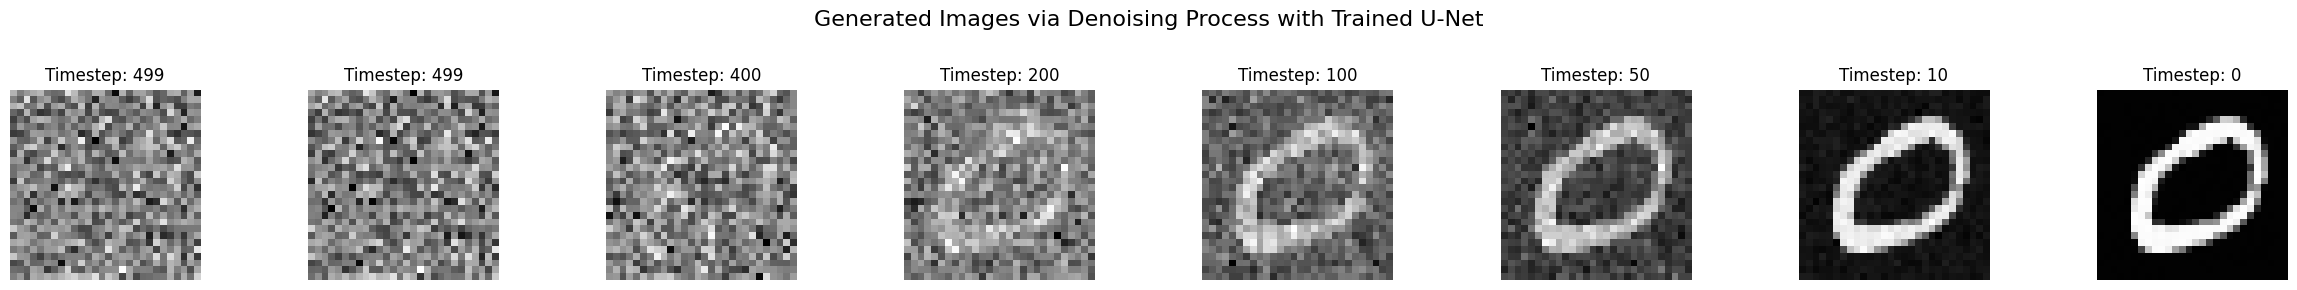

In [ ]:

def p_sample_loop_unet(model, num_diffusion_timesteps, shape, device,
                        betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev):

    # Initialize current_img with pure random noise (x_T)
    current_img = torch.randn(shape, device=device) # e.g., (1, 1, 28, 28)

    images_to_display_generated = []
    # The timesteps of interest for visualization
    visualization_output_timesteps = [num_diffusion_timesteps - 1, 400, 200, 100, 50, 10, 0]
    # Ensure 0 is always included and that steps are within bounds (num_diffusion_timesteps - 1)
    visualization_output_timesteps = [t for t in visualization_output_timesteps if t < num_diffusion_timesteps]
    visualization_output_timesteps = sorted(list(set(visualization_output_timesteps)), reverse=True)

    # Add the initial pure noise (x_T) as the very first image in the sequence.
    images_to_display_generated.append((current_img.cpu(), num_diffusion_timesteps - 1))

    # Iterate from num_diffusion_timesteps - 1 down to 0
    for i in range(num_diffusion_timesteps - 1, -1, -1):
        t_tensor = torch.tensor([i], device=device)

        # Pass model to get the noise prediction from the trained U-Net
        denoised_img = p_sample_unet(model, current_img, t_tensor,
                                       betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev)

        current_img = denoised_img # Update current_img for the next iteration

        # Store the image if it's one of the timesteps of interest for visualization
        # We store the image that corresponds to the 'i' timestep (i.e., x_i)
        if i in visualization_output_timesteps:
            images_to_display_generated.append((current_img.cpu(), i))

    # Ensure the final denoised image (timestep 0) is always captured if not already
    if images_to_display_generated[-1][1] != 0:
         images_to_display_generated.append((current_img.cpu(), 0))

    return images_to_display_generated

#  Call the p_sample_loop_unet function to generate a sequence of denoised images.
image_shape = (1, 1, 28, 28)
generated_images_with_timesteps = p_sample_loop_unet(model, num_diffusion_timesteps, image_shape, device, betas, sqrt_recip_alphas, alphas_cumprod, alphas_cumprod_prev)


# Visualize the generated images
num_plots_generated = len(generated_images_with_timesteps)
fig_gen, axes_gen = plt.subplots(1, num_plots_generated, figsize=(3 * num_plots_generated, 3))

for i, (image_tensor, t_val) in enumerate(generated_images_with_timesteps):
    # Denormalize the image from [-1, 1] to [0, 1] for visualization
    display_image = (image_tensor[0] * 0.5) + 0.5
    display_image = display_image.squeeze().cpu().numpy()

    axes_gen[i].imshow(display_image, cmap='gray')
    axes_gen[i].set_title(f'Timestep: {t_val}')
    axes_gen[i].axis('off')

plt.suptitle('Generated Images via Denoising Process with Trained U-Net', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()